# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python16 - Multi-Layer Perceptron (MLP)</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **🔹 What is a Multi-Layer Perceptron (MLP)?**  
A **Multi-Layer Perceptron (MLP)** is a type of artificial neural network (ANN) that consists of **multiple layers** of neurons. Unlike simple perceptrons, which can only handle linearly separable problems, MLP can model **complex, non-linear relationships**.

MLP is widely used for **classification and regression tasks** in machine learning.

---

### **🚀 Why Use MLP?**
✅ Can model **non-linear** relationships  
✅ Uses **backpropagation** for learning  
✅ Suitable for **both classification & regression**  
✅ Works well with **structured and unstructured data**  

---

## **🔹 Structure of an MLP**  
An MLP consists of the following layers:

1️⃣ **Input Layer**  
   - Receives raw input features (e.g., numerical values from a dataset).

2️⃣ **Hidden Layers**  
   - Apply transformations to extract meaningful patterns.  
   - Use activation functions like **ReLU**, **sigmoid**, or **tanh**.  

3️⃣ **Output Layer**  
   - Produces final predictions.  
   - For **classification**, applies **softmax** for probabilities.  
   - For **regression**, outputs continuous values.

---

### **🖼️ MLP Architecture**
![MLP Neural Network](https://www.simplilearn.com/ice9/free_resources_article_thumb/MultilayerANN_1.jpg)

---

## **🔹 MLP Forward Propagation**  
Each neuron applies a transformation:


$z = W \cdot X + b$

where:
- $ W $ = **Weights**
- $ X $ = **Input features**
- $ b $ = **Bias**

Then, an **activation function** is applied:

$
a = f(z)
$

where $ f $ can be:
- **ReLU**: $ f(x) = \max(0, x) $
- **Sigmoid**: $f(x) = \frac{1}{1+e^{-x}} $ (used for binary classification)
- **Softmax**: Converts scores into probabilities for multi-class classification.

---

## **🔹 Implementing MLP with Scikit-Learn**
We will now train an **MLP classifier** using `MLPClassifier` from `sklearn.neural_network`.


## **🔹 Key Parameters in `MLPClassifier`**
- `hidden_layer_sizes=(10, 5)`: Defines the number of neurons in each hidden layer.
- `activation='relu'`: Specifies the activation function.
- `solver='adam'`: Optimizer for weight updates (SGD, Adam, etc.).
- `max_iter=500`: Number of training iterations.

---

## **🔹 Applications of MLP**
✅ **Image Recognition**  
✅ **Spam Detection**  
✅ **Medical Diagnosis**  
✅ **Fraud Detection**  
✅ **Stock Market Prediction**  

---

## **🎯 Key Takeaways**
✔️ MLP is a powerful **neural network model** for classification and regression.  
✔️ It consists of **input, hidden, and output layers**.  
✔️ **Backpropagation & gradient descent** help optimize weights.  
✔️ Can handle **non-linearity** and **complex data patterns**.  
✔️ **Used in deep learning applications** across various domains.  

# Data loading

In [1]:
#IMPORT DATA
import pandas as pd
data = pd.read_csv('diabetes.csv')

X = data.iloc[:,0:-1]
column_names = list(X) 
y = data.iloc[:,-1] 

from sklearn.model_selection import train_test_split

#SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size =0.30, #by default is 75%-25%
                                                    #shuffle is set True by default,
                                                    stratify=y,
                                                    random_state= 123) #fix random seed for replicability

print(X_train.shape)

(537, 8)


# MLP model

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise: Multi-Layer Perceptron (MLP) with GridSearchCV**


#### **Instructions**
1. **Set up the MLP Classifier**
   - Use `MLPClassifier()` from `sklearn.neural_network`.
   - Define a grid of hyperparameters:
     - `hidden_layer_sizes`: Different neural network architectures.
     - `max_iter`: Number of iterations.
     - `alpha`: Regularization strength.

2. **Perform Grid Search**
   - Use `GridSearchCV` to search for the best combination of hyperparameters.
   - Use **3-fold cross-validation** and **F1-score** as the scoring metric.

3. **Train the Best Model**
   - Fit the best model on the training data.
   - Predict on both **training** and **test** sets.

4. **Evaluate the Performance**
   - Print **classification report** for precision, recall, and F1-score.
   - Compute and visualize the **ROC curve**.
   - Compute the **AUC (Area Under Curve) score**.

---

### **💡 Key Questions to Answer**
1. **Which set of hyperparameters yielded the best results?**
2. **How does the F1-score on the test set compare to the training set?**
3. **What does the ROC curve indicate about the classifier’s performance?**
4. **What does the AUC score tell us about the model?**

---

### **🚀 Challenge**
- Try different activation functions (`relu`, `tanh`, `logistic`).
- Experiment with different `hidden_layer_sizes`.
- Test on another dataset and compare the results.


Fitting 3 folds for each of 4 candidates, totalling 12 fits
***GRIDSEARCH RESULTS***
Best score: 0.445698 using {'alpha': 10, 'hidden_layer_sizes': (5, 3), 'max_iter': 500000}
***RESULTS ON TRAIN SET***
F1 Score:  0.021052631578947368
--
***RESULTS ON TEST SET***
F1 Score:  0.0
              precision    recall  f1-score   support

           0       0.65      0.99      0.78       150
           1       0.00      0.00      0.00        81

    accuracy                           0.65       231
   macro avg       0.32      0.50      0.39       231
weighted avg       0.42      0.65      0.51       231



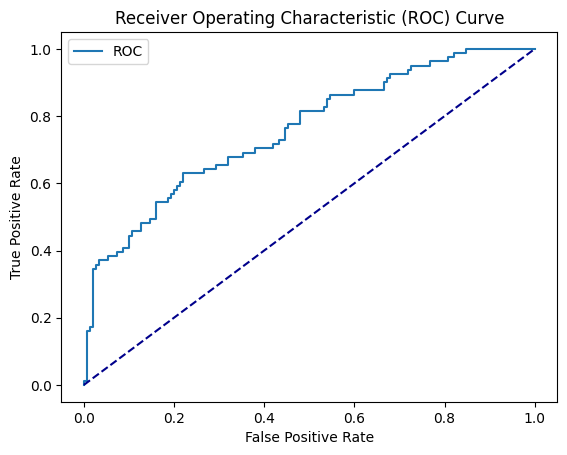

AUC: 0.76


In [2]:
'''Multi-layer Perceptron classifier'''
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import matplotlib.pyplot as plt

# Step 1: Define MLP Classifier
classifier = MLPClassifier()

# Step 2: Define Parameter Grid
parameters = {
    "hidden_layer_sizes": [(5,3,2), (5,3)],  
    "max_iter": [500000], 
    "alpha": [0.1, 10]
}

# Step 3: Perform Grid Search
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=50, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

# Step 4: Display Best Model Parameters
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

# Step 5: Train the Best Model
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

# Step 6: Evaluate Performance
print('***RESULTS ON TRAIN SET***')
print("F1 Score: ", metrics.f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("F1 Score: ", metrics.f1_score(y_test, y_pred))

# Step 7: Print Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# Step 8: Train and Evaluate with Another Configuration
model = MLPClassifier(hidden_layer_sizes=(5,3), alpha=10, max_iter=50000)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)  # Get probability predictions

# Step 9: Compute and Plot ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:,1])
plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Step 10: Compute AUC Score
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print('AUC: %.2f' % auc)